<a href="https://colab.research.google.com/github/jeeva477/NLP/blob/main/nlp_project_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
!pip install -q nltk textblob wordcloud kagglehub

# Import libraries
import pandas as pd
import nltk
import matplotlib.pyplot as plt
import kagglehub
import os
import string

from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
from wordcloud import WordCloud

# =========================================================
# Download NLTK resources
# =========================================================

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [28]:
path = kagglehub.dataset_download('datafiniti/consumer-reviews-of-amazon-products')
print('Dataset downloaded to:', path)

file_path = os.path.join(path, 'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv')

df = pd.read_csv(file_path)


Using Colab cache for faster access to the 'consumer-reviews-of-amazon-products' dataset.
Dataset downloaded to: /kaggle/input/consumer-reviews-of-amazon-products


In [29]:
df = df[['reviews.text', 'reviews.rating']].dropna()

df.rename(columns={
    'reviews.text': 'Review',
    'reviews.rating': 'Rating'
}, inplace=True)

# Use first 1000 reviews for faster processing
df = df.head(1000)

print('\\nFirst 5 Reviews:')
print(df.head())

print('\\nDataset Info:')
print(df.info())

\nFirst 5 Reviews:
                                              Review  Rating
0  I thought it would be as big as small paper bu...       3
1  This kindle is light and easy to use especiall...       5
2  Didnt know how much i'd use a kindle so went f...       4
3  I am 100 happy with my purchase. I caught it o...       5
4  Solid entry level Kindle. Great for kids. Gift...       5
\nDataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  1000 non-null   object
 1   Rating  1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB
None


In [48]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
tokenizer = RegexpTokenizer(r'\w+')

def preprocess_text(text):
    text = str(text).lower()
    tokens = tokenizer.tokenize(text)

    cleaned = []

    for word in tokens:
        if word not in stop_words and len(word) > 1: # Changed condition to len(word) > 1
            cleaned.append(lemmatizer.lemmatize(word))

    return cleaned

df['Tokens'] = df['Review'].apply(preprocess_text)

df['Clean_Text'] = df['Tokens'].apply(lambda words: ' '.join(words))

In [39]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df['Clean_Text'].apply(get_sentiment)

In [40]:
print('\\nSample Predictions:')
print(df[['Review', 'Rating', 'Sentiment']].head())


\nSample Predictions:
                                              Review  Rating Sentiment
0  I thought it would be as big as small paper bu...       3  Negative
1  This kindle is light and easy to use especiall...       5  Positive
2  Didnt know how much i'd use a kindle so went f...       4  Positive
3  I am 100 happy with my purchase. I caught it o...       5  Positive
4  Solid entry level Kindle. Great for kids. Gift...       5  Positive


In [41]:
sentiment_counts = df['Sentiment'].value_counts()

print('\\nSentiment Counts:')
print(sentiment_counts)


\nSentiment Counts:
Sentiment
Positive    913
Neutral      55
Negative     32
Name: count, dtype: int64


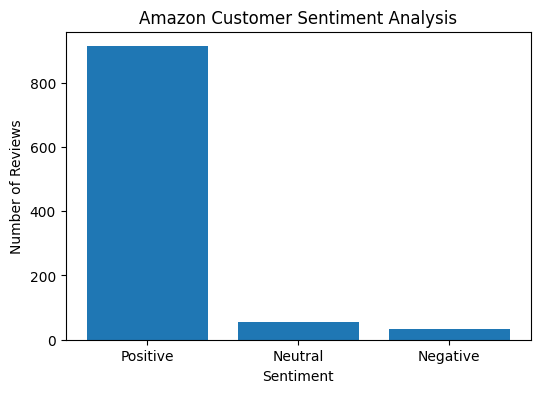

In [42]:
plt.figure(figsize=(6,4))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.title('Amazon Customer Sentiment Analysis')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

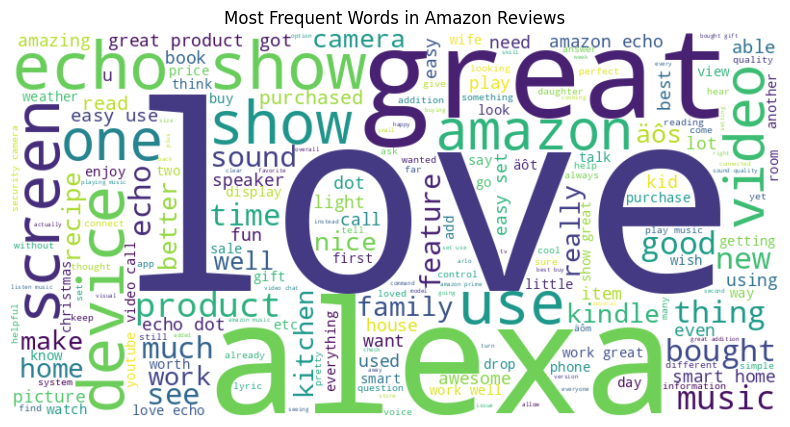

In [43]:
all_words = ' '.join(df['Clean_Text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Amazon Reviews')
plt.show()

In [44]:
negative_reviews = df[df['Sentiment'] == 'Negative']

print('\\nTop 10 Negative Reviews:')
print(negative_reviews['Review'].head(10).to_string(index=False))

\nTop 10 Negative Reviews:
I thought it would be as big as small paper but...
I bought my Kindle about 2 months ago and the b...
I've wanted a kindle for a while and decided to...
The battery doesn't last as long as was adverti...
it would not load my books proper. took a dozen...
I especially like the Amazon has a system to co...
The screen is too dark, and cannot adjust the b...
I have to say it was a little confusing and fru...
I‚Äôve asked itquestions and answers were unkno...
I bought the echo after seeing it demonstrated ...


In [45]:
from collections import Counter

negative_words = ' '.join(negative_reviews['Clean_Text']).split()

common_negative = Counter(negative_words).most_common(10)

print('\\nMost Common Complaint Words:')
for word, freq in common_negative:
    print(f'{word}: {freq}')

\nMost Common Complaint Words:
show: 18
echo: 15
alexa: 15
amazon: 14
device: 9
work: 9
useless: 9
would: 8
kindle: 7
screen: 7


In [46]:
total = len(df)
positive = (df['Sentiment'] == 'Positive').sum()
negative = (df['Sentiment'] == 'Negative').sum()
neutral = (df['Sentiment'] == 'Neutral').sum()

print('\\nBusiness Insights')
print('--------------------------------')
print(f'Total Reviews      : {total}')
print(f'Positive Reviews   : {positive}')
print(f'Negative Reviews   : {negative}')
print(f'Neutral Reviews    : {neutral}')

print(f'Positive %         : {(positive/total)*100:.2f}%')
print(f'Negative %         : {(negative/total)*100:.2f}%')

if negative > 0:
    print('\\nSuggestions:')
    print('- Improve product quality')
    print('- Improve packaging')
    print('- Improve delivery speed')
    print('- Strengthen customer support')
    print('- Investigate common complaint words shown above')
else:
    print('\\nCustomers are highly satisfied.')



\nBusiness Insights
--------------------------------
Total Reviews      : 1000
Positive Reviews   : 913
Negative Reviews   : 32
Neutral Reviews    : 55
Positive %         : 91.30%
Negative %         : 3.20%
\nSuggestions:
- Improve product quality
- Improve packaging
- Improve delivery speed
- Strengthen customer support
- Investigate common complaint words shown above
